# Universal Automatic Elbow Detection (G-UAED) for Lasso (non-uniform sampling)

This notebook implements the Generalized Universal Automatic Elbow Detection (G-UAED) algorithm, originally written in MATLAB by Samuel Escudero, Luca Martino, Roberto San Millán, and Eduardo Morgado.

It loads error curves and finds the optimal elbow point as well as an uncertainty interval.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os

In [2]:
def interval_aed_fun_lasso(V, kx):
    """
    Calculates the uncertainty interval for the elbow point.
    
    Parameters:
    V (numpy.ndarray): Error curve values.
    kx (numpy.ndarray): Number of links (x-axis).
    
    Returns:
    list: [k_1^*, k_2^*] defining the uncertainty interval.
    """
    V = V - np.min(V)
    kmax = kx[-1]
    
    min_now = float('inf')
    indices_now = [None, None]
    x = kx
    x2 = kx
    
    # Iterate through all pairs of points
    for i in range(len(x)):
        for j in range(i + 1, len(x)):
            # Calculate areas of the three regions (trapezoid, trapezoid, triangle)
            A1 = ((V[0] + V[i]) * (x[i] - x[0])) / 2.0 if i > 0 else 0 # Adjusted to include (x[i] - x[0]) as per paper mathematically
            # original MATLAB code has A1=((V(1)+V(i))*x(i))/2 which implicitly assumes x[0] is 0 or very close.
            A1 = ((V[0] + V[i]) * x[i]) / 2.0
            
            A2 = ((V[i] + V[j]) * (x2[j] - x[i])) / 2.0
            
            A3 = ((kmax - x2[j]) * V[j]) / 2.0
            
            E2 = A1 + A2 + A3
            
            if E2 < min_now:
                min_now = E2
                indices_now = [kx[i], kx[j]]
                
    return indices_now

In [3]:
# === Configuration ===
file_path = 'results/opt_lamb_araus/sem_und_withth_err.npz'
file_type = '.npz' # '.mat' or '.npz'

SELECTED_KEY = 'B' # Change to 'A', 'B', 'C', or 'D' as needed
# EXPLANATION OF KEYS (MATLAB Variables):
    # KEY 'A' (e.g., Curva_noth_err_out.mat): Looking just the connections of the two outputs with possible inter-link
    # KEY 'B' (e.g., Curva_noth_err.mat): Considering all the connections with all the variables (with possible link within the two outputs)
    # KEY 'C' (e.g., Curva_UNC_noth_err_out.mat): Looking just the connections of the two outputs WITHOUT possible inter-link
    # KEY 'D' (e.g., Curva_UNC_noth_err.mat): Considering all the connections with all the variables (WITHOUT possible link within the two outputs)

# Text to display on the plot (optional)
if SELECTED_KEY == 'A':
    plot_text = ["Looking just the", "connections of the two outputs", "with possible inter-link"]
elif SELECTED_KEY == 'B':
    plot_text = ["Considering all the connections", "with all the variables", "(with possible link within the", "two outputs)"]
elif SELECTED_KEY == 'C':
    plot_text = ["Looking just the", "connections of the two outputs", "WITHOUT possible inter-link"]
elif SELECTED_KEY == 'D':
    plot_text = ["Considering all the connections", "with all the variables", "(WITHOUT possible link within the", "two outputs)"]
else:
    plot_text = None

axis_limits = None

# Save Figure Configuration
SAVE = True
# =====================


In [4]:
# === Load Data ===
if file_type == '.mat':
    mat_data = scipy.io.loadmat(file_path)
    # Attempt to automatically find the data matrix (usually 'A', 'B', 'C', 'D' or similar in MATLAB)
    data_keys = [k for k in mat_data.keys() if not k.startswith('__')]
    
    if SELECTED_KEY in mat_data:
        data_matrix = mat_data[SELECTED_KEY]
        print(f"Loaded key '{SELECTED_KEY}'")
    else:
        raise ValueError(f"Key '{SELECTED_KEY}' not found in the .mat file. Available keys: {data_keys}")
        
elif file_type == '.npy':
    data_matrix = np.load(file_path)
elif file_type == '.npz':
    npz_data = np.load(file_path, allow_pickle=True)
    npz_keys = list(npz_data.keys())
    # If the .npz is from our optimization scripts, it has 'lambdas', 'sparsity', 'err'
    if 'lambdas' in npz_keys and 'sparsity' in npz_keys and 'err' in npz_keys:
        data_matrix = np.column_stack((npz_data['lambdas'], npz_data['sparsity'], npz_data['err']))
        print(f"Loaded 'lambdas', 'sparsity', 'err' from .npz")
    # Otherwise fallback to basic loading if there's a SELECTED_KEY generic array
    elif SELECTED_KEY in npz_keys:
        data_matrix = npz_data[SELECTED_KEY]
        print(f"Loaded key '{SELECTED_KEY}' from .npz")
    elif len(npz_keys) > 0:
        data_matrix = npz_data[npz_keys[0]]
        print(f"Loaded first available key '{npz_keys[0]}' from .npz (SELECTED_KEY '{SELECTED_KEY}' not found)")
    else:
        raise ValueError("The .npz file is empty.")
else:
    raise ValueError("Unsupported file_type. Please use '.mat', '.npy', or '.npz'")

print(f"Loaded data from {file_path} with shape {data_matrix.shape}")

Loaded 'lambdas', 'sparsity', 'err' from .npz
Loaded data from results/opt_lamb_araus/sem_und_withth_err.npz with shape (40, 3)


In [5]:
# === Data Processing ===
# The MATLAB code reverses the array: A(end:-1:1, :)
A = data_matrix[::-1, :]

lambdaLASSO = A[:, 0]
kx = A[:, 1]
V = A[:, 2]

# Normalize V for processing so the estimation algorithms behave identically to MATLAB
V_norm = V - np.min(V)

# Point Estimation (Geometric method from MATLAB)
lam = V_norm[0] / kx[-1]
aux = np.abs((V_norm[0] - lam * kx) - V_norm)

# Find max distance point
pos_max = np.argmax(aux)
Elbow2 = kx[pos_max]
optimal_lambda = lambdaLASSO[pos_max]

# Interval Estimation (G-UAED)
interval_links = interval_aed_fun_lasso(V_norm, kx)

# Find corresponding lambdas for the interval
pos_int_1 = np.where(kx == interval_links[0])[0][0]
pos_int_2 = np.where(kx == interval_links[1])[0][0]
interval_lambda = [lambdaLASSO[pos_int_1], lambdaLASSO[pos_int_2]]

print('-' * 52)
print('RESULTS')
print('-' * 52)
print(f'Optimal number of links: {Elbow2}')
print('-' * 52)
print(f'Optimal lambda of LASSO: {optimal_lambda}')
print('-' * 52)
print(f'Uncertainty interval (links): {interval_links}')
print(f'Uncertainty interval (lambda): {interval_lambda}')
print('-' * 52)


----------------------------------------------------
RESULTS
----------------------------------------------------
Optimal number of links: 462.0
----------------------------------------------------
Optimal lambda of LASSO: 4.729766810045442
----------------------------------------------------
Uncertainty interval (links): [374.0, 1372.0]
Uncertainty interval (lambda): [8.78385264722725, 0.5630674773863622]
----------------------------------------------------


Figura guardada en results/guad/elbow_plot_B.png y .pdf


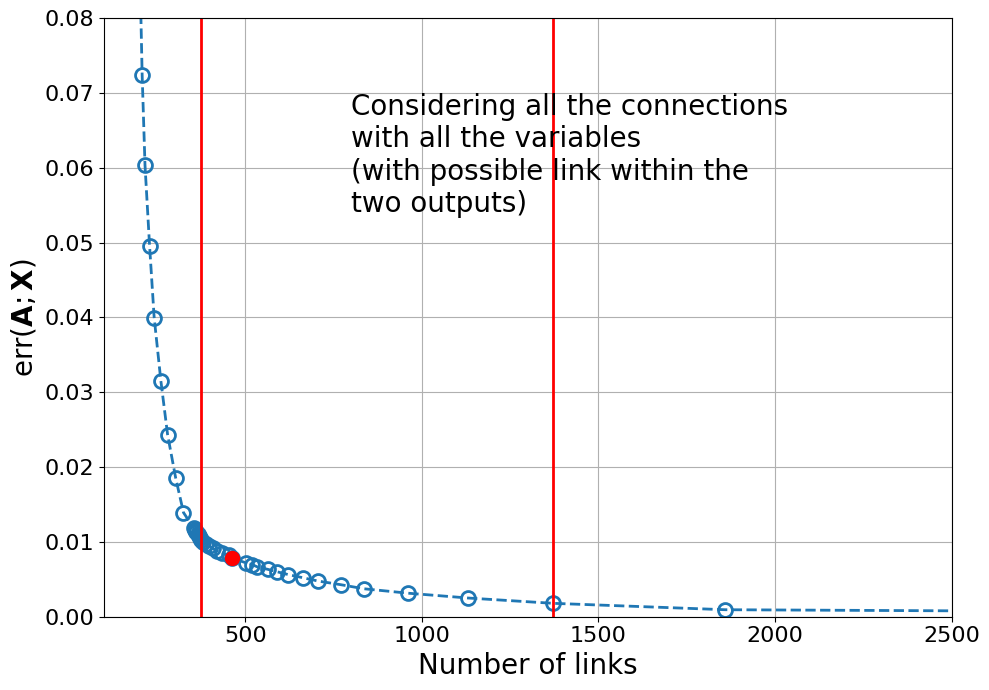

In [6]:
# === Plotting ===
plt.figure(figsize=(10, 7))
plt.plot(kx, V, 'o--', linewidth=2, markersize=10, markerfacecolor='none', markeredgecolor='tab:blue', markeredgewidth=2, color='tab:blue')
plt.plot(Elbow2, V[pos_max], 'ro--', markerfacecolor='r', markeredgecolor='r', markersize=10)

# Plot Interval Lines
plt.axvline(x=interval_links[0], color='r', linestyle='-', linewidth=2)
plt.axvline(x=interval_links[1], color='r', linestyle='-', linewidth=2)

# Formatting
plt.xlabel('Number of links', fontsize=20)
plt.ylabel(r'$\mathrm{err}(\mathbf{A}; \mathbf{X})$', fontsize=20) # Using raw string for LaTeX interpretation
plt.box(True)
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Optional texts dynamically positioned using Axes fractions (x=0.35, y=0.95 relative to axes area)
if plot_text:
    plt.text(0.35, 0.95, '\n'.join(plot_text), fontsize=20, verticalalignment='top', transform=plt.gca().transAxes)

if axis_limits:
    plt.axis(axis_limits)

plt.tight_layout()

if SAVE:
    import os
    os.makedirs('results/guad', exist_ok=True)
    plt.savefig(f'results/guad/elbow_plot_{SELECTED_KEY}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'results/guad/elbow_plot_{SELECTED_KEY}.pdf', bbox_inches='tight')
    print(f'Figura guardada en results/guad/elbow_plot_{SELECTED_KEY}.png y .pdf')

plt.show()
